In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
%matplotlib inline


In [24]:
df_true = pd.read_csv(r"C:\Users\srujan  R\OneDrive\Desktop\True.csv")

In [25]:
df_true.head(4)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"


In [5]:
df_fake = pd.read_csv(r"C:\Users\srujan  R\OneDrive\Desktop\Fake.csv")

In [6]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [8]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [9]:
df_fake['label'] = 'fake'
df_true['label'] = 'real'

In [10]:
df = pd.concat([df_fake , df_true]).reset_index(drop = True)

In [11]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [13]:
df[df['label'] == "real"].head()

,title,text,subject,date,label
23481,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",real
23482,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",real
23483,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",real
23484,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",real
23485,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",real


In [14]:
print('combined shape' , df.shape)

combined shape (44898, 5)


In [15]:
df['label'].value_counts()

label
fake    23481
real    21417
Name: count, dtype: int64

In [16]:
df.describe(include = 'all')

,title,text,subject,date,label
count,44898,44898,44898,44898,44898
unique,38729,38646,8,2397,2
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",fake
freq,14,627,11272,182,23481


In [17]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

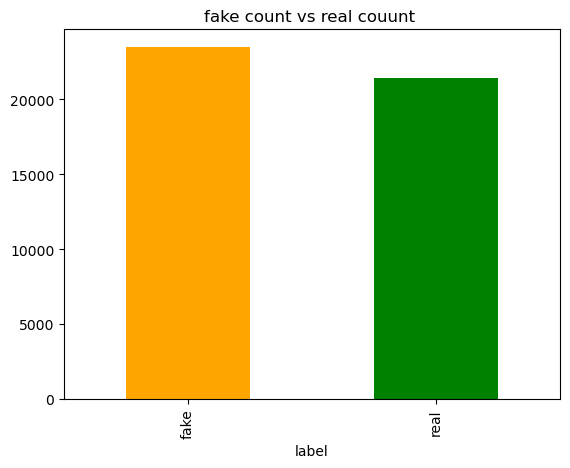

In [18]:
df['label'].value_counts().plot(kind = 'bar', title = "fake count vs real couunt ", color = ['orange' ,'green'])
plt.show()

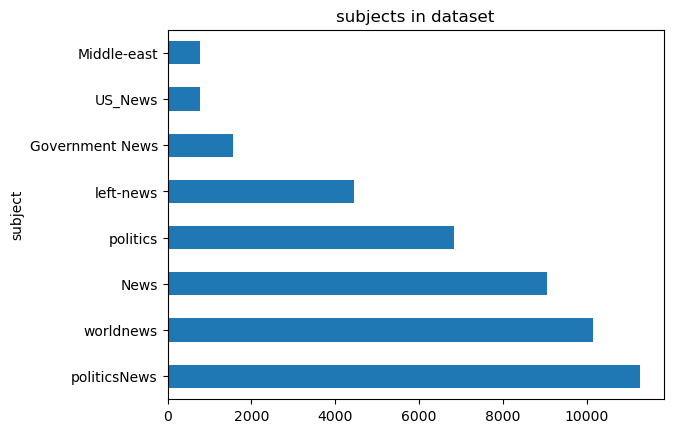

In [19]:
df['subject'].value_counts().plot(kind = 'barh', title = 'subjects in dataset')
plt.show()

2015-05-01 00:00:00 2017-12-31 00:00:00


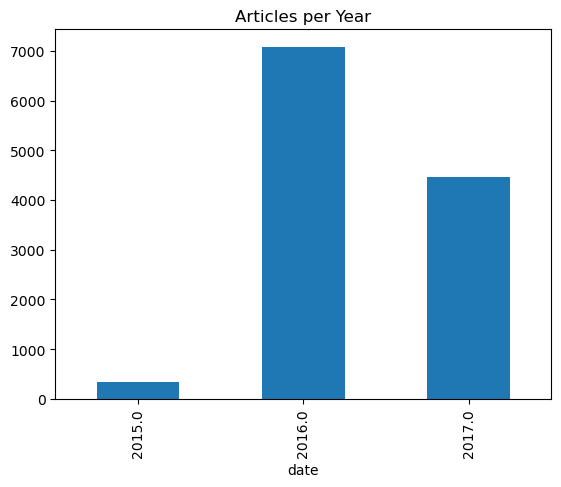

In [47]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(df['date'].min(), df['date'].max())

# Plot distribution over time
df['date'].dt.year.value_counts().sort_index().plot(kind='bar', title='Articles per Year')
plt.show()


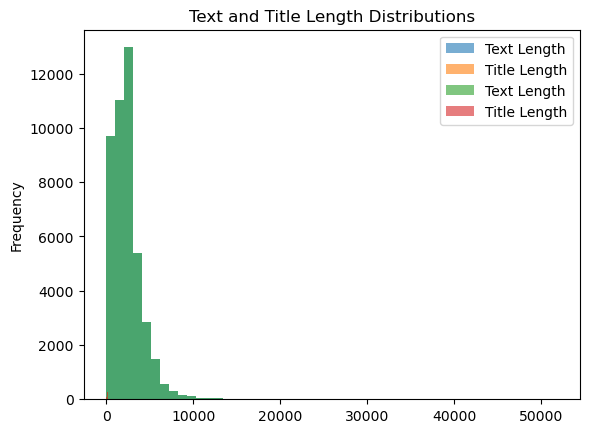

In [51]:
df['text_len'] = df['text'].astype(str).apply(len)
df['title_len'] = df['title'].astype(str).apply(len)

# Histograms
df['text_len'].plot.hist(bins=50, alpha=0.6, label='Text Length')
df['title_len'].plot.hist(bins=50, alpha=0.6, label='Title Length')
plt.legend()
plt.title('Text and Title Length Distributions')
plt.show()


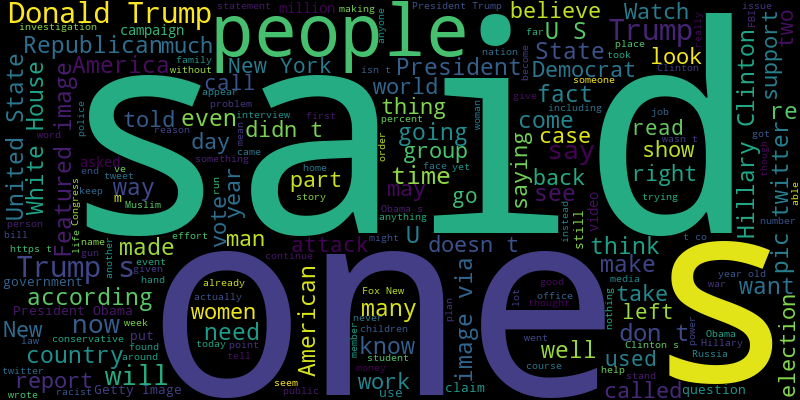

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Real news
real_text = " ".join(df[df['label'] == 'real']['text'].dropna().astype(str).values)
WordCloud(width=800, height=400).generate(real_text).to_image()

# Fake news
fake_text = " ".join(df[df['label'] == 'fake']['text'].dropna().astype(str).values)
WordCloud(width=800, height=400).generate(fake_text).to_image()
